<a href="https://colab.research.google.com/github/Pensive1881/DSR44_2025/blob/main/V02_02a_Intermediate_Fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2a. Intermediate Fusion



In the last lab, we successfully created a multimodal model. However, the performance was not much better than a Lidar-based model. In this notebook, we will explore a more challenging dataset and different fusion techniques to overcome this challenge.

These experiments will take a moment to run. While these models are training, please continue to read on and try to predict what the results will be.

#### Learning Objectives

The goals of this notebook are to:
* Compare four types of multimodal fusion techniques:
  * Early fusion
  * Late fusion
  * Intermediate fusion with concatenation
  * Intermediate fusion with matrix multiplication

Let's begin by loading the libraries necessary for this lab.

## Setup for Google Colab

This notebook has been adapted to run on Google Colab with GPU support.


In [2]:
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive

Mounted at /gdrive
/gdrive


### Data Path Configuration

Set the path to your data directory in Google Drive. Make sure you have uploaded the `multimodal_training_workshop/data` folder to your Google Drive.


In [3]:
from pathlib import Path
import os

DATA_PATH = Path('/gdrive/MyDrive/multimodal_training_workshop/data')
print(f"Data path: {DATA_PATH}")
print(f"Data path exists: {DATA_PATH.exists()}")

Data path: /gdrive/MyDrive/multimodal_training_workshop/data
Data path exists: True


### GPU Check

Verify that GPU is available and working.


In [4]:
!nvidia-smi

Thu Nov 20 09:09:08 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Imports

Load all necessary libraries for this lab.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from PIL import Image
from IPython.display import Image as IPy_img

import matplotlib.colors as colors

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

## Utility Functions



In [6]:
IMG_SIZE = 64
BATCH_SIZE = 32
VALID_BATCHES = 10
N = 1000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss_func = nn.MSELoss()


def hex_to_RGB(hex_str):
    """ #FFFFFF -> [255,255,255]"""
    #Pass 16 to the integer function for change of base
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]


def get_color_gradient(c1, c2, c3, n1, n2):
    """
    Given two hex colors, returns a color gradient
    with n colors.
    """
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    c3_rgb = np.array(hex_to_RGB(c3))/255
    mix_pcts_c1_c2 = [x/(n1-1) for x in range(n1)]
    mix_pcts_c2_c3 = [x/(n2-1) for x in range(n2)]
    rgb_c1_c2 = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts_c1_c2]
    rgb_c2_c3 = [((1-mix)*c2_rgb + (mix*c3_rgb)) for mix in mix_pcts_c2_c3]
    rgb_colors = rgb_c1_c2 + rgb_c2_c3
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


cmap = colors.ListedColormap(get_color_gradient("#000000", "#76b900", "#f1ffd9", 64, 128))


def format_positions(positions):
    return ['{0: .3f}'.format(x) for x in positions]

def get_outputs(model, batch, inputs_idx):
    inputs = batch[inputs_idx].to(device)
    target = batch[-1].to(device)
    outputs = model(inputs)
    return outputs, target

def print_loss(epoch, loss, outputs, target, is_train=True, is_debug=False):
    loss_type = "train loss:" if is_train else "valid loss:"
    print("epoch", str(epoch), loss_type, str(loss))
    if is_debug:
        print("example pred:", format_positions(outputs[0].tolist()))
        print("example real:", format_positions(target[0].tolist()))


def train_model(model, optimizer, input_fn, epochs, train_dataloader, valid_dataloader, target_idx=-1):
    train_losses = []
    valid_losses = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for step, batch in enumerate(train_dataloader):
            optimizer.zero_grad()
            target = batch[target_idx].to(device)
            outputs = model(*input_fn(batch))

            loss = loss_func(outputs, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss = train_loss / (step + 1)
        train_losses.append(train_loss)
        print_loss(epoch, train_loss, outputs, target, is_train=True)

        model.eval()
        valid_loss = 0
        for step, batch in enumerate(valid_dataloader):
            target = batch[target_idx].to(device)
            outputs = model(*input_fn(batch))
            valid_loss += loss_func(outputs, target).item()
        valid_loss = valid_loss / (step + 1)
        valid_losses.append(valid_loss)
        print_loss(epoch, valid_loss, outputs, target, is_train=False)
    return train_losses, valid_losses


img_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),  # Scales data into [0,1]
])

def get_torch_xyza(lidar_depth, azimuth, zenith):
    x = lidar_depth * torch.sin(-azimuth[:, None]) * torch.cos(-zenith[None, :])
    y = lidar_depth * torch.cos(-azimuth[:, None]) * torch.cos(-zenith[None, :])
    z = lidar_depth * torch.sin(-zenith[None, :])
    a = torch.where(lidar_depth < 50.0, torch.ones_like(lidar_depth), torch.zeros_like(lidar_depth))
    xyza = torch.stack((x, y, z, a))
    return xyza


class ReplicatorDataset(Dataset):
    def __init__(self, root_dir, start_idx, stop_idx):
        self.root_dir = root_dir
        self.rgb_imgs = []
        self.lidar_depths = []
        self.positions = pd.read_csv('https://github.com/andandandand/practical-computer-vision/blob/main/artifacts/positions.csv?raw=1').values[start_idx:stop_idx]


        azimuth_path = os.path.join(self.root_dir, "azimuth.npy")
        zenith_path = os.path.join(self.root_dir, "zenith.npy")

        if not os.path.exists(azimuth_path):
            raise FileNotFoundError(f"azimuth.npy not found at {azimuth_path}")
        if not os.path.exists(zenith_path):
            raise FileNotFoundError(f"zenith.npy not found at {zenith_path}")

        azimuth = np.load(azimuth_path)
        zenith = np.load(zenith_path)
        self.azimuth = torch.from_numpy(azimuth).to(device)
        self.zenith = torch.from_numpy(zenith).to(device)

        for idx in range(start_idx, stop_idx):
            file_number = "{:04d}".format(idx)
            rbg_img = Image.open(self.root_dir + "/rgb/" + file_number + ".png")
            rbg_img = img_transforms(rbg_img).to(device)
            self.rgb_imgs.append(rbg_img)

            lidar_depth = np.load(self.root_dir + "/lidar/" + file_number + ".npy")
            lidar_depth = torch.from_numpy(lidar_depth).to(torch.float32).to(device)
            self.lidar_depths.append(lidar_depth)

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, idx):
        rbg_img = self.rgb_imgs[idx]
        lidar_depth = self.lidar_depths[idx]
        lidar_xyza = get_torch_xyza(lidar_depth, self.azimuth, self.zenith)

        position = self.positions[idx]
        position = torch.from_numpy(position).to(torch.float32).to(device)

        return rbg_img, lidar_xyza, position


def get_replicator_dataloaders(root_dir):
    train_data = ReplicatorDataset(root_dir, 0, N-VALID_BATCHES*BATCH_SIZE)
    train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    valid_data = ReplicatorDataset(root_dir, N-VALID_BATCHES*BATCH_SIZE, N)
    valid_dataloader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
    return train_data, train_dataloader, valid_data, valid_dataloader

def animate_3D_points(file_path, fig, ax, x, y, z, c):
    def anim_init():
        ax.scatter(x, y, z, color=c, marker='o')
        return fig,

    def animate(i):
        ax.view_init(elev=30., azim=i)
        return fig,

    if not os.path.exists(file_path):
        anim = animation.FuncAnimation(
            fig, animate, init_func=anim_init, frames=360, interval=20, blit=True
        )
        anim.save(file_path, fps=30)

## 2.1 The Dataset

In the previous lab, our dataset was composed of three different shapes: a cube, a sphere, and a torus. Because the LiDAR data can more directly calculate the center of each object, the RGB data was ignored in our multimodal models.

In this lab, we will use three of the same shape: a red cube, a green cube, and a blue cube. Since LiDAR systems cannot see color, a model based only on LiDAR data would have a hard time distinguishing which cube is which. On the other hand, RGB data would be able to distinguish between the cubes, but an RGB model would have a harder time calculating position in general. Let's see if we can create a model with the best of both worlds.

Before we create any multimodal models, let's see how single modal models would perform on this dataset. In the interest of time, we've already ran a training simulation and collected the results. If you would like to verify, this can be done by running the previous notebook, but changing the data directory to `data/replicator_data_cubes/`.

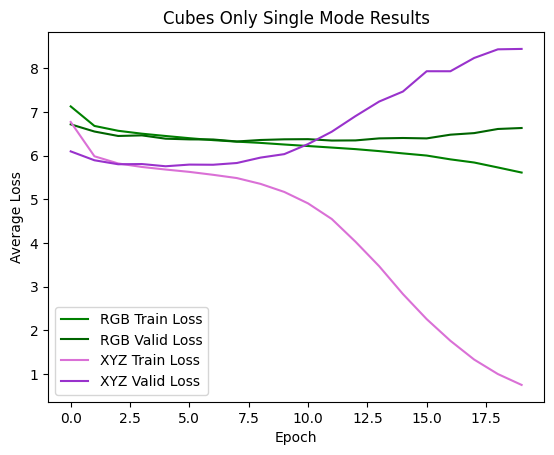

In [7]:
import pandas as pd
single_mode_data = pd.read_csv('https://raw.githubusercontent.com/andandandand/practical-computer-vision/refs/heads/main/artifacts/cubes_only_single_mode_results.csv').values

plot_x = range(len(single_mode_data))
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.plot(plot_x, single_mode_data[:, 1], "green", label = "RGB Train Loss")
plt.plot(plot_x, single_mode_data[:, 2], "darkgreen", label = "RGB Valid Loss")
plt.plot(plot_x, single_mode_data[:, 3], "orchid", label = "XYZ Train Loss")
plt.plot(plot_x, single_mode_data[:, 4], "darkorchid", label = "XYZ Valid Loss")
plt.title("Cubes Only Single Mode Results")
plt.legend()
plt.show()

With this dataset, a model based on RGB images has a validation loss of about 6. We have 3 objects, so the predicted position of each object is off by 2 units. Omniverse position units are relative, meaning it's not tied to a real-world unit of measurement like feet or centimeters. Many 3D modelers and applications suggest 1 unit should be 1 meter.

On the other hand, the LiDAR model achieved a loss of less than 1 on the train dataset, but over 8 on the validation dataset. This is a classic case of overfitting. Because the LiDAR model can't find the logical pattern to calculate the position of these objects, it instead attempted to memorize the train dataset.

So, to put things into perspective, our objects have a 10 unit by 10 unit range it can randomly place itself in along each of the X, Y, and Z axis. In other words, the objects spawn in a 1000 unit cubed area, and the diagonal along that area is about 17.3 units. In this case, the loss is the same as our error. If the average error for each object is 2 units, that's about 11.6% of the length of diagonal range. Not bad, but not great either.



Our dataset has the same structure as last time: the first set of values are the `rgb_img`s, the second set is the `lidar_xyza` data, and the third set of values are the object positions. Let's verify that the shapes are what we expect.

In [8]:
train_data, train_dataloader, valid_data, valid_dataloader = get_replicator_dataloaders(str(DATA_PATH / "replicator_data_cubes/"))

for i, sample in enumerate(train_data):
    print(i, *(x.shape for x in sample))
    break

0 torch.Size([4, 64, 64]) torch.Size([4, 64, 64]) torch.Size([9])


## 2.2 Model Composition

Time to get these experiments rolling. We're going to test the performance of four models:
* `early_net`: A multimodal model using early fusion
* `late_net`: A multimodal model using late fusion
* `cat_net`: A multimodal model using intermediate fusion with [concatenation](https://pytorch.org/docs/main/generated/torch.cat.html)
* `matmul_net`: A multimodal model using intermediaet fusion with [matrix multiplication](https://pytorch.org/docs/stable/generated/torch.matmul.html)

### 2.2.1 EarlyNet

First, let's make a generic convolutional neural network that we can use with both `early_net` and `late_net`.

In [9]:
num_positions = 9

class Net(nn.Module):
    def __init__(self, in_ch):
        kernel_size = 3
        super().__init__()
        flattened_size = 200 * 8 * 8
        self.conv1 = nn.Conv2d(in_ch, 50, kernel_size, padding=1)
        self.conv2 = nn.Conv2d(50, 100, kernel_size, padding=1)
        self.conv3 = nn.Conv2d(100, 200, kernel_size, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(flattened_size, 1000)
        self.fc2 = nn.Linear(1000, 100)
        self.fc3 = nn.Linear(100, num_positions)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

We've created a function in [py](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html) called `train_model` to train each of our experiments. It still needs a function to extract the appropriate information from the dataloader. In the case of `early_net`, the rgb and xyz values should be [concatenated](https://pytorch.org/docs/main/generated/torch.cat.html) before feeding the data into the model.

In [10]:
def get_early_inputs(batch):
    inputs_rgb = batch[0].to(device)
    inputs_xyz = batch[1].to(device)
    inputs_mm_early = torch.cat((inputs_rgb, inputs_xyz), 1)
    return (inputs_mm_early,)

Time for the first experiment. Please run the cell below and continue reading. Training will take some time to complete.

In [11]:
epochs = 20
early_net = Net(8).to(device)
early_opt = Adam(early_net.parameters(), lr=0.0001)
early_train_losses, early_valid_losses = train_model(
    early_net,
    early_opt,
    get_early_inputs,
    epochs,
    train_dataloader,
    valid_dataloader
)

epoch 0 train loss: 8.496646631331672
epoch 0 valid loss: 8.254435396194458
epoch 1 train loss: 8.228875500815255
epoch 1 valid loss: 7.8086652755737305
epoch 2 train loss: 7.4142780758085705
epoch 2 valid loss: 7.1868866920471195
epoch 3 train loss: 6.874442781720843
epoch 3 valid loss: 7.020571947097778
epoch 4 train loss: 6.700533821469262
epoch 4 valid loss: 6.9953676700592045
epoch 5 train loss: 6.607354186830067
epoch 5 valid loss: 7.005795574188232
epoch 6 train loss: 6.401660010928199
epoch 6 valid loss: 6.87224063873291
epoch 7 train loss: 6.17083283833095
epoch 7 valid loss: 6.829834985733032
epoch 8 train loss: 6.014841579255604
epoch 8 valid loss: 6.707053709030151
epoch 9 train loss: 5.886490027109782
epoch 9 valid loss: 6.6033087253570555
epoch 10 train loss: 5.71607696442377
epoch 10 valid loss: 6.728676462173462
epoch 11 train loss: 5.5263671875
epoch 11 valid loss: 6.735475015640259
epoch 12 train loss: 5.380396434238979
epoch 12 valid loss: 6.711447620391846
epoch 13 

### 2.2.2 LateNet

Next, let's create `late_net`. This will use two of our generic `Net`s that we created in the last section. Unlike the last lab, these nets will not be pretrained, allowing for a fairer comparison with `early_net`. However, since there are two `Net`s, `late_net` has nearly twice as many paramaters as `early_net`, so a perfectly fair comparison would be difficult to achieve. It's still worthwhile to try new things. Let's see how they compare.

In [12]:
rgb_net = Net(4).to(device)
xyz_net = Net(4).to(device)

class LateNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.rgb = rgb_net
        self.xyz = xyz_net
        self.fc1 = nn.Linear(num_positions * 2, num_positions * 10)
        self.fc2 = nn.Linear(num_positions * 10, num_positions)

    def forward(self, x_rgb, x_xyz):
        x_rgb = self.rgb(x_rgb)
        x_xyz = self.xyz(x_xyz)
        x = torch.cat((x_rgb, x_xyz), 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

For the rest of these experiments, we will use the same `get_inputs` function. `late_net`, like `cat_net` and `matmul_net`, has two different paths for the data to flow through the network.

In [13]:
def get_inputs(batch):
    inputs_rgb = batch[0].to(device)
    inputs_xyz = batch[1].to(device)
    return (inputs_rgb, inputs_xyz)

Finally, let's define `late_net` and run the experiment. Please run the cell below and read on. Because `late_net` has more parameters, this also means it will take longer to train.

In [14]:
late_net = LateNet().to(device)
late_opt = Adam(late_net.parameters(), lr=0.0001)
late_train_losses, late_valid_losses = train_model(
    late_net,
    late_opt,
    get_inputs,
    epochs,
    train_dataloader,
    valid_dataloader,
)

epoch 0 train loss: 8.484134560539609
epoch 0 valid loss: 8.288184213638306
epoch 1 train loss: 8.407419454483758
epoch 1 valid loss: 8.13999605178833
epoch 2 train loss: 8.045624914623442
epoch 2 valid loss: 7.64922776222229
epoch 3 train loss: 7.5351545470101495
epoch 3 valid loss: 7.4218395233154295
epoch 4 train loss: 7.145510355631511
epoch 4 valid loss: 7.155910634994507
epoch 5 train loss: 6.867740131559826
epoch 5 valid loss: 6.966817235946655
epoch 6 train loss: 6.656460398719425
epoch 6 valid loss: 6.715627527236938
epoch 7 train loss: 6.2784306435357955
epoch 7 valid loss: 6.265311765670776
epoch 8 train loss: 5.809034642719087
epoch 8 valid loss: 5.686322736740112
epoch 9 train loss: 5.372542721884591
epoch 9 valid loss: 5.490305662155151
epoch 10 train loss: 5.032181739807129
epoch 10 valid loss: 5.139093971252441
epoch 11 train loss: 4.806112902505057
epoch 11 valid loss: 5.06608510017395
epoch 12 train loss: 4.532335463024321
epoch 12 valid loss: 4.9700212478637695
epoch

### 2.2.3 CatNet

For the next experiment, we'll try something completely new. Instead of joining our data streams at the beginning or end of the model, we'll mix them together somewhere in the middle. In this case, we'll have two convolution paths: one for RGB data, and one for XYZ data. We can almost think of a convolution function as taking in some sheets of paper and outputting a different number of sheets of paper. It's like we're taking these output sheets from our two data streams and stacking them on top of each other.

Before moving on, take a moment to look at the architecture below. Can you see where the two pathways meet? It doesn't appear in the `__init__` function. That `cat` operation occurs in the `forward` pass. In the generic `Net` architecture, the last convolution had `200` kernels. In this case we have `2` final convolutions with `100` kernels each.

In [15]:
class ConcatIntermediateNet(nn.Module):
    def __init__(self, rgb_ch, xyz_ch):
        kernel_size = 3
        num_positions = 9
        super().__init__()
        self.rgb_conv1 = nn.Conv2d(rgb_ch, 25, kernel_size, padding=1)
        self.rgb_conv2 = nn.Conv2d(25, 50, kernel_size, padding=1)
        self.rgb_conv3 = nn.Conv2d(50, 100, kernel_size, padding=1)

        self.xyz_conv1 = nn.Conv2d(xyz_ch, 25, kernel_size, padding=1)
        self.xyz_conv2 = nn.Conv2d(25, 50, kernel_size, padding=1)
        self.xyz_conv3 = nn.Conv2d(50, 100, kernel_size, padding=1)

        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(200 * 8 * 8, 1000)
        self.fc2 = nn.Linear(1000, 100)
        self.fc3 = nn.Linear(100, num_positions)

    def forward(self, x_rgb, x_xyz):
        x_rgb = self.pool(F.relu(self.rgb_conv1(x_rgb)))
        x_rgb = self.pool(F.relu(self.rgb_conv2(x_rgb)))
        x_rgb = self.pool(F.relu(self.rgb_conv3(x_rgb)))

        x_xyz = self.pool(F.relu(self.xyz_conv1(x_xyz)))
        x_xyz = self.pool(F.relu(self.xyz_conv2(x_xyz)))
        x_xyz = self.pool(F.relu(self.xyz_conv3(x_xyz)))

        x = torch.cat((x_rgb, x_xyz), 1)
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

The top of this architecture looks like late fusion, but the bottom of it looks like early fusion. That means the number of parameters for `cat_net` is less that `late_net`. However, more parameters are not always better. Let's see if this is true by running the cell below. This experiment will take some time. Please continue to read on.

In [16]:
epochs = 20
cat_net = ConcatIntermediateNet(4, 4).to(device)
cat_net_opt = Adam(cat_net.parameters(), lr=0.0001)
cat_net_train_losses, cat_net_valid_losses = train_model(
    cat_net,
    cat_net_opt,
    get_inputs,
    epochs,
    train_dataloader,
    valid_dataloader,
)

epoch 0 train loss: 8.533087185450963
epoch 0 valid loss: 8.194456911087036
epoch 1 train loss: 8.178042184738885
epoch 1 valid loss: 7.833056020736694
epoch 2 train loss: 7.5534136181785945
epoch 2 valid loss: 7.177727699279785
epoch 3 train loss: 6.9317718006315685
epoch 3 valid loss: 6.929549932479858
epoch 4 train loss: 6.586892218816848
epoch 4 valid loss: 6.725400161743164
epoch 5 train loss: 6.387317203340077
epoch 5 valid loss: 6.520262908935547
epoch 6 train loss: 5.977216311863491
epoch 6 valid loss: 6.441004705429077
epoch 7 train loss: 5.486857187180292
epoch 7 valid loss: 5.62512354850769
epoch 8 train loss: 4.711124238513765
epoch 8 valid loss: 4.921069049835205
epoch 9 train loss: 4.003041437694004
epoch 9 valid loss: 4.328254914283752
epoch 10 train loss: 3.5491218793959844
epoch 10 valid loss: 4.084601259231567
epoch 11 train loss: 3.241757256644113
epoch 11 valid loss: 3.9866650342941283
epoch 12 train loss: 3.137193032673427
epoch 12 valid loss: 3.8309032917022705
ep

### 2.2.4 MatmulNet

We're finally at our last experiment, `matmul_net`. This architecture is very similar to `cat_net`, but with one key difference. Instead of concatenating the outputs of the two final convolutions, we're going to broadcast [matrix multiply](https://en.wikipedia.org/wiki/Matrix_multiplication) the outputs together. Since they're both squares of the same shape, this is a valid operation.

The [Hadamard product](https://en.wikipedia.org/wiki/Hadamard_product_(matrices)), where we multiply the matrices elementwise, would also be valid. However, matrix multiplication allows for different parts of the matrices to interact with each other, increasing the chance our network finds a useful multiplication operation.

> **Note:** The matmul.png visualization has been removed for Colab compatibility. The matrix multiplication operation combines the two 100-channel feature maps by performing batched matrix multiplication, resulting in 100 output feature maps.

Since we're matrix multiplying instead of concatenating, our `2` x `100` convolution output gets reduced down to `100` matrices. As they are still matrices, they should be `flattened` before passing the information to the dense `linear` section of the network.

In [17]:
class MatmulIntermediateNet(nn.Module):
    def __init__(self, rgb_ch, xyz_ch):
        kernel_size = 3
        color_chs = 9
        num_positions = 9
        super().__init__()
        self.rgb_conv1 = nn.Conv2d(rgb_ch, 25, kernel_size, padding=1)
        self.rgb_conv2 = nn.Conv2d(25, 50, kernel_size, padding=1)
        self.rgb_conv3 = nn.Conv2d(50, 100, kernel_size, padding=1)

        self.xyz_conv1 = nn.Conv2d(xyz_ch, 25, kernel_size, padding=1)
        self.xyz_conv2 = nn.Conv2d(25, 50, kernel_size, padding=1)
        self.xyz_conv3 = nn.Conv2d(50, 100, kernel_size, padding=1)

        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(100 * 8 * 8, 1000)
        self.fc2 = nn.Linear(1000, 100)
        self.fc3 = nn.Linear(100, num_positions)

    def forward(self, x_rgb, x_xyz):
        x_rgb = self.pool(F.relu(self.rgb_conv1(x_rgb)))
        x_rgb = self.pool(F.relu(self.rgb_conv2(x_rgb)))
        x_rgb = self.pool(F.relu(self.rgb_conv3(x_rgb)))

        x_xyz = self.pool(F.relu(self.xyz_conv1(x_xyz)))
        x_xyz = self.pool(F.relu(self.xyz_conv2(x_xyz)))
        x_xyz = self.pool(F.relu(self.xyz_conv3(x_xyz)))

        x = torch.matmul(x_rgb, x_xyz)
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [18]:
epochs = 20
matmul_net = MatmulIntermediateNet(4, 4).to(device)
matmul_net_opt = Adam(matmul_net.parameters(), lr=0.0001)
matmul_net_train_losses, matmul_net_valid_losses = train_model(
    matmul_net,
    matmul_net_opt,
    get_inputs,
    epochs,
    train_dataloader,
    valid_dataloader,
)

epoch 0 train loss: 8.476457073574974
epoch 0 valid loss: 8.265253162384033
epoch 1 train loss: 8.2927519934518
epoch 1 valid loss: 7.750583267211914
epoch 2 train loss: 7.7230982553391225
epoch 2 valid loss: 7.411167192459106
epoch 3 train loss: 7.2535379727681475
epoch 3 valid loss: 6.686547422409058
epoch 4 train loss: 6.418620313916888
epoch 4 valid loss: 5.830756282806396
epoch 5 train loss: 5.701536087762742
epoch 5 valid loss: 5.46153712272644
epoch 6 train loss: 5.277911254337856
epoch 6 valid loss: 4.988194727897644
epoch 7 train loss: 4.788598094667707
epoch 7 valid loss: 4.773073649406433
epoch 8 train loss: 4.5184427215939476
epoch 8 valid loss: 4.807686591148377
epoch 9 train loss: 4.329092468534197
epoch 9 valid loss: 4.489068150520325
epoch 10 train loss: 4.0558997222355435
epoch 10 valid loss: 4.453474497795105
epoch 11 train loss: 3.9074649697258357
epoch 11 valid loss: 4.379717326164245
epoch 12 train loss: 3.759473210289365
epoch 12 valid loss: 4.253653979301452
epoc

## 2.3 Results

Congrats on making it to the end. There's a good chance at this point, the experiment is still running. For now, please move on to the [next notebook](02b_Contrastive_Pretraining.ipynb) in the meantime. Please return when you are finished to see the comparison graph below.

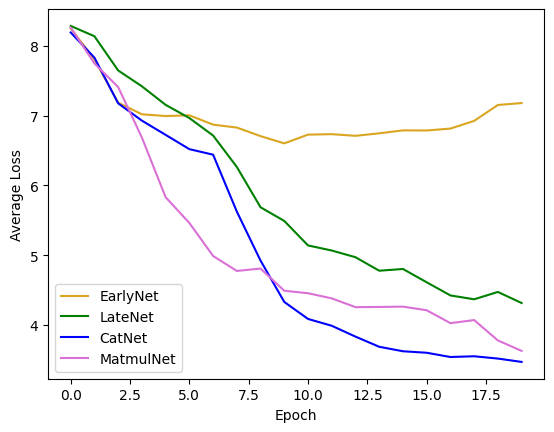

In [19]:
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.plot(plot_x, early_valid_losses, "goldenrod", label = "EarlyNet")
plt.plot(plot_x, late_valid_losses, "green", label = "LateNet")
plt.plot(plot_x, cat_net_valid_losses, "blue", label = "CatNet")
plt.plot(plot_x, matmul_net_valid_losses, "orchid", label = "MatmulNet")
plt.legend()
plt.show()